# PRESEIS Model Building Examples

This notebook has two distinct purposes.

1. Show a simple single-model workflow: one station profile, one small local volume, and one bent cross-section, all built with the same sampling API.
2. Compare multiple processed models on that same station set and section geometry.

The Groningen no-anhydrite dataset is one of the comparison models in part 2 rather than a separate workflow.

In [1]:
import importlib
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path.cwd().resolve().parent))

import preseis.model_building.examples as example_helpers

importlib.reload(example_helpers)

from preseis.model_building import sample_velocity_model
from preseis.model_building.examples import (
    DEFAULT_VS_PARAMETERS,
    format_depth_axis,
    load_example_models,
    load_knmi_stations,
    make_depth_axis,
    make_local_volume_grid,
    make_polyline_section_line,
    plot_section_map,
    sample_model_collection,
    select_mode,
    with_distance_km,
)

SINGLE_MODEL_NAME = "velmod-3.1"
MODEL_NAMES = [
    "velmod-3.1",
    "velmod-3.2",
    "velmod-4",
    "groningen",
    "groningen-no-anhydrite",
]
COMPARISON_MODEL_NAMES = [
    model_name for model_name in MODEL_NAMES if model_name != SINGLE_MODEL_NAME
]
MODEL_LABELS = {
    "velmod-3.1": "VELMOD 3.1",
    "velmod-3.2": "VELMOD 3.2",
    "velmod-4": "VELMOD 4",
    "groningen": "Groningen 2017",
    "groningen-no-anhydrite": "Groningen 2017 (No-anhydrite)",
}
MODEL_COLORS = {
    "velmod-3.1": "C0",
    "velmod-3.2": "C2",
    "velmod-4": "C3",
    "groningen": "C1",
    "groningen-no-anhydrite": "C4",
}

plt.rcParams["figure.figsize"] = (12, 8)

In [2]:
models = load_example_models(["dgm", *MODEL_NAMES])

for name in ["dgm", *MODEL_NAMES]:
    print(f"{name}: sizes={dict(models[name].sizes)}")
    print(f"  data variables: {', '.join(models[name].data_vars)}")

dgm: sizes={'y': 2212, 'x': 1256, 'unit': 12}
  data variables: tvd, ordering
velmod-3.1: sizes={'y': 553, 'x': 314, 'unit': 15, 'summary_statistic': 2}
  data variables: V0, Vint, layer, k, ordering, V0_filled
velmod-3.2: sizes={'y': 553, 'x': 314, 'unit': 15, 'summary_statistic': 2}
  data variables: V0, Vint, layer, k, ordering, V0_filled
velmod-4: sizes={'y': 2211, 'x': 1256, 'unit': 7}
  data variables: V0, Vint, tvd, k, ordering, V0_filled
groningen: sizes={'unit': 10, 'x': 1450, 'y': 1198}
  data variables: tvd, V0, V0_filled, k, relationship_type, vs_slope, vs_intercept, ordering
groningen-no-anhydrite: sizes={'unit': 10, 'x': 1450, 'y': 1198}
  data variables: tvd, V0, V0_filled, k, relationship_type, vs_slope, vs_intercept, ordering


In [3]:
depths = make_depth_axis(max_depth=3500.0, sample_count=401)
knmi_stations = load_knmi_stations()
selected_station_names = ["G330", "G620", "G360"]
section_label = " → ".join(selected_station_names)
groningen_stations = knmi_stations.sel(Station=selected_station_names)
single_model = models[SINGLE_MODEL_NAME]
single_station_name = selected_station_names[0]
single_station = groningen_stations.sel(Station=single_station_name)

groningen_stations[["Longitude", "Latitude"]].to_dataframe()

,Longitude,Latitude
Station,,
G330,6.670763,53.24991
G620,6.841949,53.38698
G360,6.924454,53.26505


## 1. Single-Model Workflow

Start with one model and the core `sample_velocity_model(...)` API. The first cell below sketches a common use case: query the local P-wave and S-wave velocity at a hypothetical source location `(longitude, latitude, z)`, where `z` is negative below NAP. The following cells scale that same call up to a full profile, a small local volume, and a bent section.

### Point Query For A Source Location

If you already have a candidate source location and just want the local velocities at that one point, this is the core call.

In [4]:
source_lon = float(single_station["Longitude"].item())
source_lat = float(single_station["Latitude"].item())
source_depth_m = -1000.0

source_sample = sample_velocity_model(
    source_lon,
    source_lat,
    source_depth_m,
    crs="EPSG:4326",
    depth_model=models["dgm"],
    velocity_model=models[SINGLE_MODEL_NAME],
    **DEFAULT_VS_PARAMETERS,
)

{
    "longitude": source_lon,
    "latitude": source_lat,
    "depth_m_nap": source_depth_m,
    "vp_mps": float(select_mode(source_sample, "P").item()),
    "vs_mps": float(select_mode(source_sample, "S").item()),
}

{'longitude': 6.670763,
 'latitude': 53.24991,
 'depth_m_nap': -1000.0,
 'vp_mps': 3190.649861542074,
 'vs_mps': 1578.340180649268}

### Turn The Same Location Into A Profile

Keep the same horizontal source position and model, but replace the scalar depth with a depth axis to sample a full 1D profile.

In [5]:
profile_depths = depths

single_profile = sample_velocity_model(
    source_lon,
    source_lat,
    profile_depths,
    crs="EPSG:4326",
    depth_model=models["dgm"],
    velocity_model=models[SINGLE_MODEL_NAME],
    **DEFAULT_VS_PARAMETERS,
)

single_profile

<xarray.Dataset> Size: 21kB
Dimensions:       (unit: 11, z: 401, mode: 2)
Coordinates:
  * unit          (unit) <U4 176B 'AT' 'CK' 'DC' 'KN' ... 'RN' 'RO' 'S' 'ZE'
  * z             (z) float64 3kB -0.0 8.75 17.5 ... 3.482e+03 3.491e+03 3.5e+03
  * mode          (mode) <U1 8B 'P' 'S'
    spatial_ref   int64 8B 0
    x             float64 8B 7.45e+05
    y             float64 8B 5.907e+06
Data variables:
    V0            (unit) float64 88B 2.314e+03 2.302e+03 ... 2.226e+03 4.51e+03
    k             (unit) float64 88B 0.436 0.889 0.261 0.536 ... 0.309 0.52 0.0
    depth         (unit) float64 88B -1.581e+03 -1.53e+03 ... -2.677e+03
    ordering      (unit) int64 88B 16 6 25 7 2 1 20 19 23 11 22
    V0_sd         (unit) float64 88B 170.5 124.9 167.0 ... 191.9 237.4 205.6
    unit_samples  (z) <U4 6kB 'NU' 'NU' 'NU' 'NU' 'NU' ... 'NU' 'NU' 'NU' 'NU'
    unit_mask     (unit, z) bool 4kB False False False ... False False False
    Vinst         (mode, z) float64 6kB 1.714e+03 1.717e+03 ... nan nan

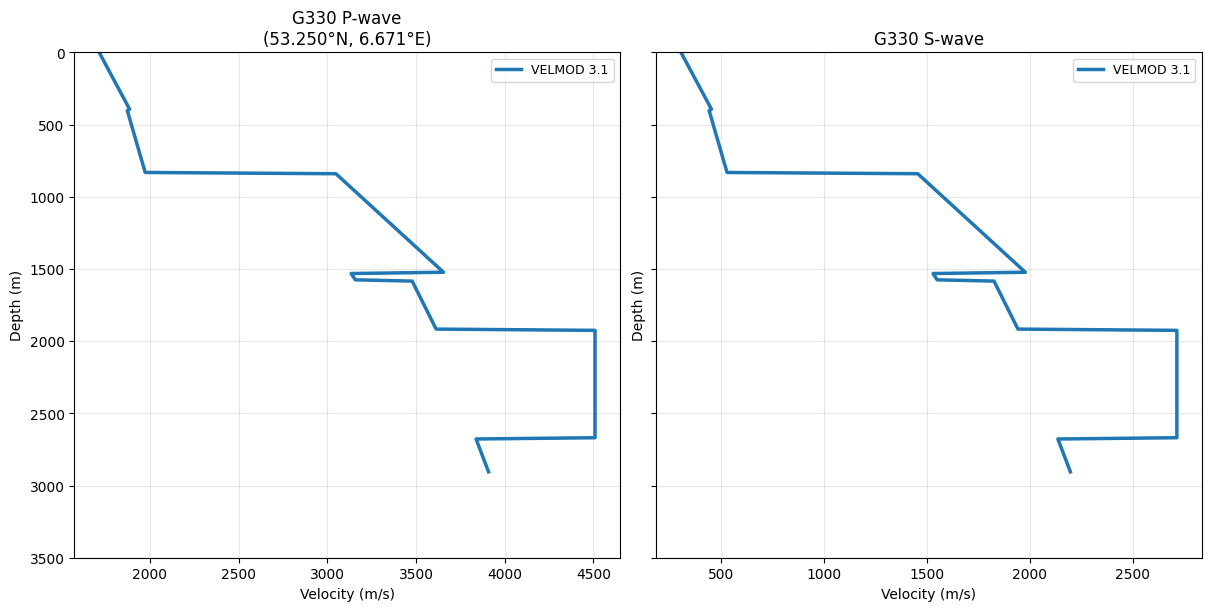

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True, constrained_layout=True)

p_profile = select_mode(single_profile, "P")
s_profile = select_mode(single_profile, "S")
lat = float(single_station["Latitude"].item())
lon = float(single_station["Longitude"].item())

p_profile.plot.line(
    y="z",
    ax=axes[0],
    color=MODEL_COLORS[SINGLE_MODEL_NAME],
    linewidth=2.5,
    label=MODEL_LABELS[SINGLE_MODEL_NAME],
)
axes[0].set_xlabel("Velocity (m/s)")
axes[0].set_title(f"{single_station_name} P-wave\n({lat:.3f}°N, {lon:.3f}°E)")
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9)
format_depth_axis(axes[0], p_profile["z"])

s_profile.plot.line(
    y="z",
    ax=axes[1],
    color=MODEL_COLORS[SINGLE_MODEL_NAME],
    linewidth=2.5,
    label=MODEL_LABELS[SINGLE_MODEL_NAME],
)
axes[1].set_xlabel("Velocity (m/s)")
axes[1].set_title(f"{single_station_name} S-wave")
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9)
format_depth_axis(axes[1], s_profile["z"])

plt.show()

### Small Local Volume

The same `sample_velocity_model(...)` call also works on a 2D longitude/latitude grid. Here a small volume is sampled around the same station so the simple use case expands from one point to a local cube without changing APIs.

In [7]:
volume_grid = make_local_volume_grid(
    float(single_station["Longitude"].item()),
    float(single_station["Latitude"].item()),
    half_width_km=5.0,
    point_count=50,
)
volume_depths = make_depth_axis(max_depth=3000.0, sample_count=301)

single_volume = sample_velocity_model(
    volume_grid["longitude"],
    volume_grid["latitude"],
    volume_depths,
    crs="EPSG:4326",
    depth_model=models["dgm"],
    velocity_model=single_model,
    **DEFAULT_VS_PARAMETERS,
)

print(
    f"Volume size: {single_volume.sizes['northing_km']} × "
    f"{single_volume.sizes['easting_km']} × {single_volume.sizes['z']} samples"
)
print(
    f"Horizontal extent: ±{float(np.abs(volume_grid['easting_km']).max().item()):.1f} km around {single_station_name}"
)

Volume size: 50 × 50 × 301 samples
Horizontal extent: ±5.0 km around G330


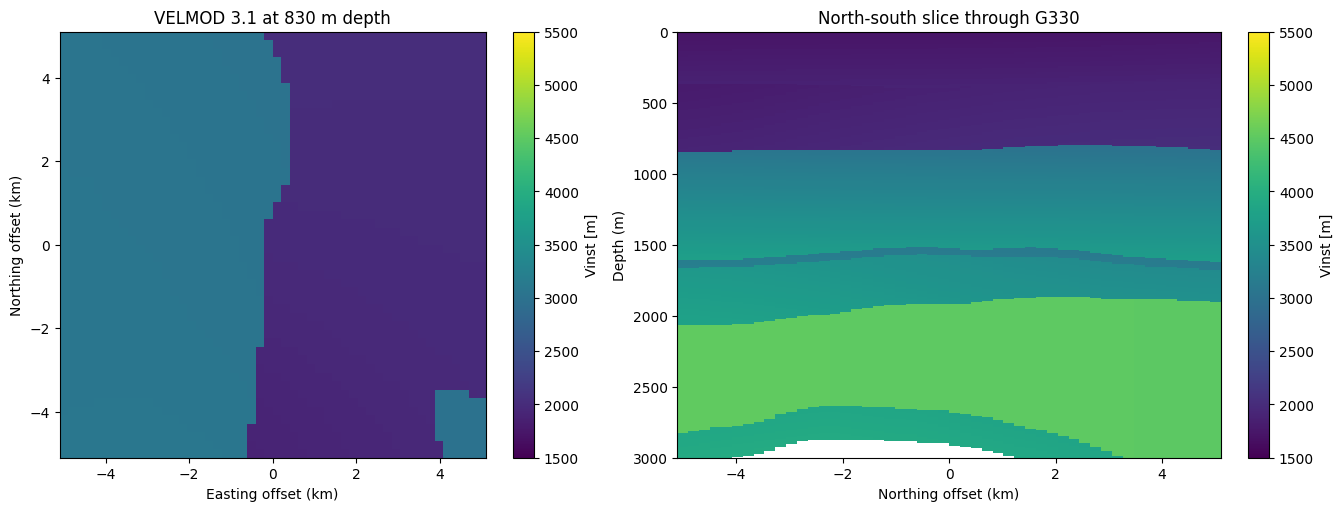

In [8]:
volume_p = select_mode(single_volume, "P").transpose("z", "northing_km", "easting_km")
volume_spread = volume_p.std(("northing_km", "easting_km"), skipna=True)
volume_slice_depth_m = float(volume_spread.idxmax("z").item())
volume_center_offset_km = 0.0

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

volume_p.sel(z=volume_slice_depth_m, method="nearest").plot(
    x="easting_km",
    y="northing_km",
    ax=axes[0],
    cmap="viridis",
    vmin=1500,
    vmax=5500,
)
axes[0].set_title(
    f"{MODEL_LABELS[SINGLE_MODEL_NAME]} at {volume_slice_depth_m:.0f} m depth"
)
axes[0].set_xlabel("Easting offset (km)")
axes[0].set_ylabel("Northing offset (km)")
axes[0].set_aspect("equal")

volume_p.sel(easting_km=volume_center_offset_km, method="nearest").plot(
    x="northing_km",
    y="z",
    ax=axes[1],
    cmap="viridis",
    vmin=1500,
    vmax=5500,
)
axes[1].set_title(f"North-south slice through {single_station_name}")
axes[1].set_xlabel("Northing offset (km)")
format_depth_axis(axes[1], volume_p["z"])

plt.show()

### Bent Section Along The Shared Station Path

The last single-model step uses the same API again, but now on a bent line through the selected stations. That closes the simple workflow before the notebook switches to multi-model comparison.

In [9]:
section = make_polyline_section_line(
    groningen_stations["Longitude"],
    groningen_stations["Latitude"],
    point_count=120,
)

single_section = with_distance_km(
    sample_velocity_model(
        section["longitude"],
        section["latitude"],
        depths,
        crs="EPSG:4326",
        depth_model=models["dgm"],
        velocity_model=single_model,
        **DEFAULT_VS_PARAMETERS,
    ),
    section,
)

print(f"Section profile: {section_label}")
print(
    f"Section length: {float(section['distance_km'].max().item()):.1f} km, "
    f"points: {section.sizes['inline']}"
)

Section profile: G330 → G620 → G360
Section length: 33.7 km, points: 120


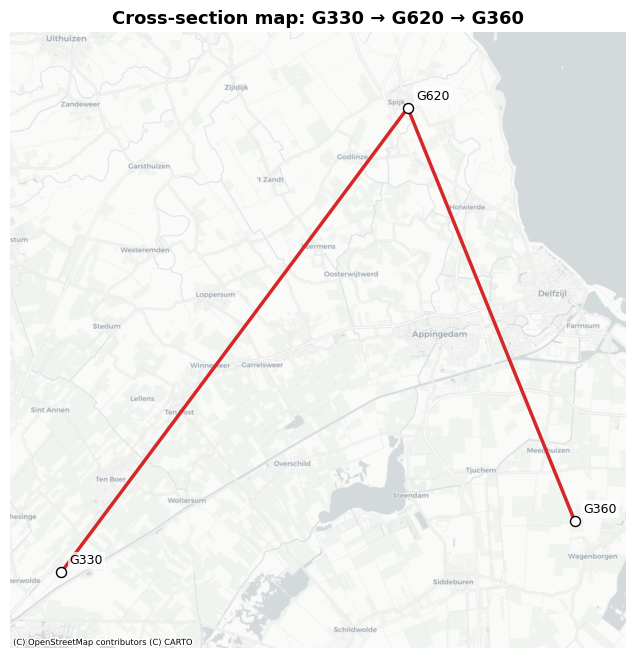

In [10]:
fig, ax = plt.subplots(figsize=(8, 8))
plot_section_map(ax, groningen_stations, section)
ax.set_title(
    f"Cross-section map: {section_label}",
    fontsize=13,
    fontweight="bold",
)
plt.show()

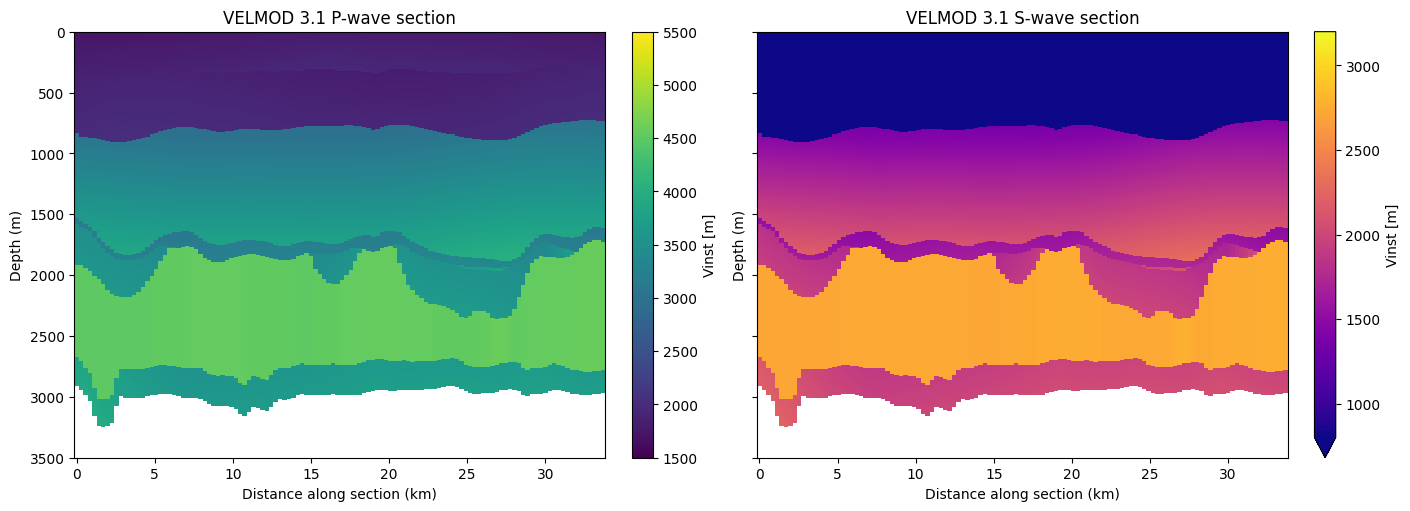

In [11]:
single_section_p = select_mode(single_section, "P").transpose("z", "distance_km")
single_section_s = select_mode(single_section, "S").transpose("z", "distance_km")

fig, axes = plt.subplots(
    1, 2, figsize=(14, 5), sharex=True, sharey=True, constrained_layout=True
)

single_section_p.plot(
    x="distance_km",
    y="z",
    ax=axes[0],
    cmap="viridis",
    add_colorbar=True,
    vmin=1500,
    vmax=5500,
)
axes[0].set_title(f"{MODEL_LABELS[SINGLE_MODEL_NAME]} P-wave section")
axes[0].set_xlabel("Distance along section (km)")
format_depth_axis(axes[0], single_section_p["z"])

single_section_s.plot(
    x="distance_km",
    y="z",
    ax=axes[1],
    cmap="plasma",
    add_colorbar=True,
    vmin=800,
    vmax=3200,
)
axes[1].set_title(f"{MODEL_LABELS[SINGLE_MODEL_NAME]} S-wave section")
axes[1].set_xlabel("Distance along section (km)")
format_depth_axis(axes[1], single_section_s["z"])

plt.show()

## 2. Model Comparison

Reuse the same stations and the same bent section path, but now sample all processed models so the differences and cross-sections are clearly part of the comparison workflow.

In [12]:
station_samples = sample_model_collection(
    models,
    MODEL_NAMES,
    groningen_stations["Longitude"],
    groningen_stations["Latitude"],
    depths,
    crs="EPSG:4326",
    vs_parameters=DEFAULT_VS_PARAMETERS,
    depth_model=models["dgm"],
)

section_samples = {
    model_name: with_distance_km(sampled_model, section)
    for model_name, sampled_model in sample_model_collection(
        models,
        MODEL_NAMES,
        section["longitude"],
        section["latitude"],
        depths,
        crs="EPSG:4326",
        vs_parameters=DEFAULT_VS_PARAMETERS,
        depth_model=models["dgm"],
    ).items()
}

print(f"Comparison models: {', '.join(COMPARISON_MODEL_NAMES)}")
print(f"Shared section length: {float(section['distance_km'].max().item()):.1f} km")

Comparison models: velmod-3.2, velmod-4, groningen, groningen-no-anhydrite
Shared section length: 33.7 km


### Single-Station Differences

With the shared comparison samples in place, use the VELMOD 3.1 station profile as a baseline and compare the other models at one Groningen station.


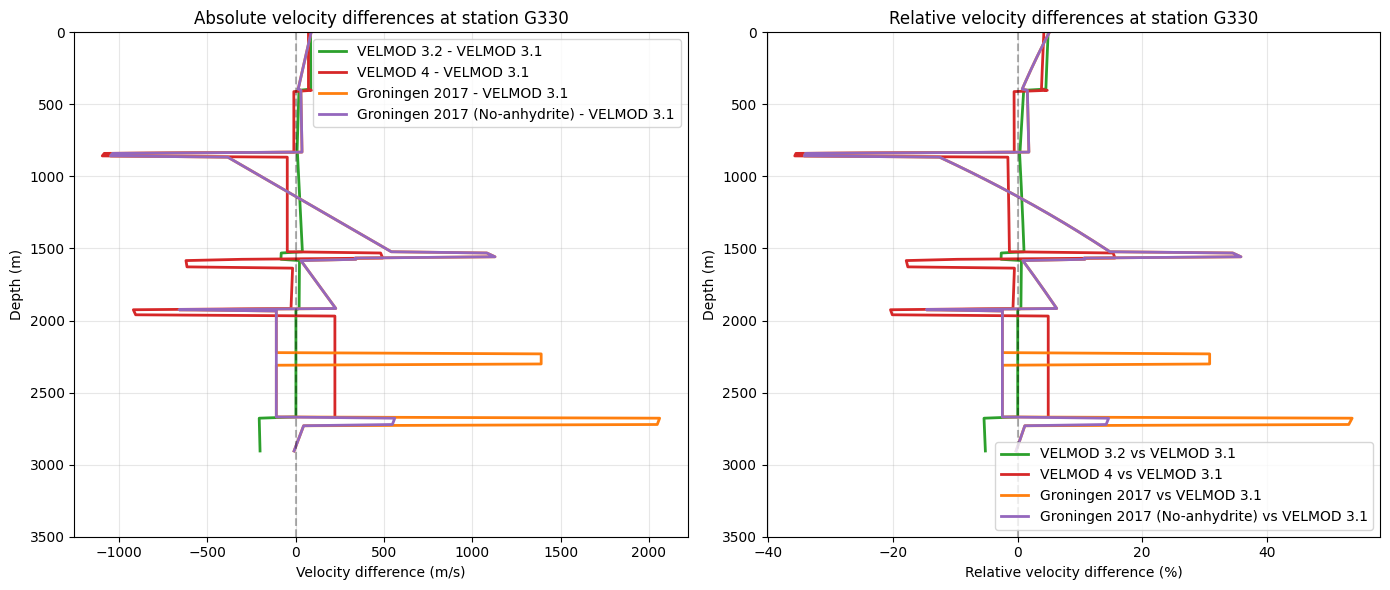

In [13]:
station = selected_station_names[0]
station_baseline = select_mode(station_samples["velmod-3.1"].sel(Station=station), "P")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for model_name in COMPARISON_MODEL_NAMES:
    diff = (
        select_mode(station_samples[model_name].sel(Station=station), "P")
        - station_baseline
    )
    rel_diff = 100.0 * diff / station_baseline

    diff.plot.line(
        y="z",
        ax=ax1,
        label=f"{MODEL_LABELS[model_name]} - VELMOD 3.1",
        color=MODEL_COLORS[model_name],
        linewidth=2,
    )
    rel_diff.plot.line(
        y="z",
        ax=ax2,
        label=f"{MODEL_LABELS[model_name]} vs VELMOD 3.1",
        color=MODEL_COLORS[model_name],
        linewidth=2,
    )

ax1.axvline(0, color="k", linestyle="--", alpha=0.3)
ax1.set_xlabel("Velocity difference (m/s)")
ax1.set_title(f"Absolute velocity differences at station {station}")
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)
format_depth_axis(ax1, station_baseline["z"])

ax2.axvline(0, color="k", linestyle="--", alpha=0.3)
ax2.set_xlabel("Relative velocity difference (%)")
ax2.set_title(f"Relative velocity differences at station {station}")
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)
format_depth_axis(ax2, station_baseline["z"])

plt.tight_layout()
plt.show()

### All-Model Cross-Sections

Stack the shared section across all models once the comparison samples have been created.


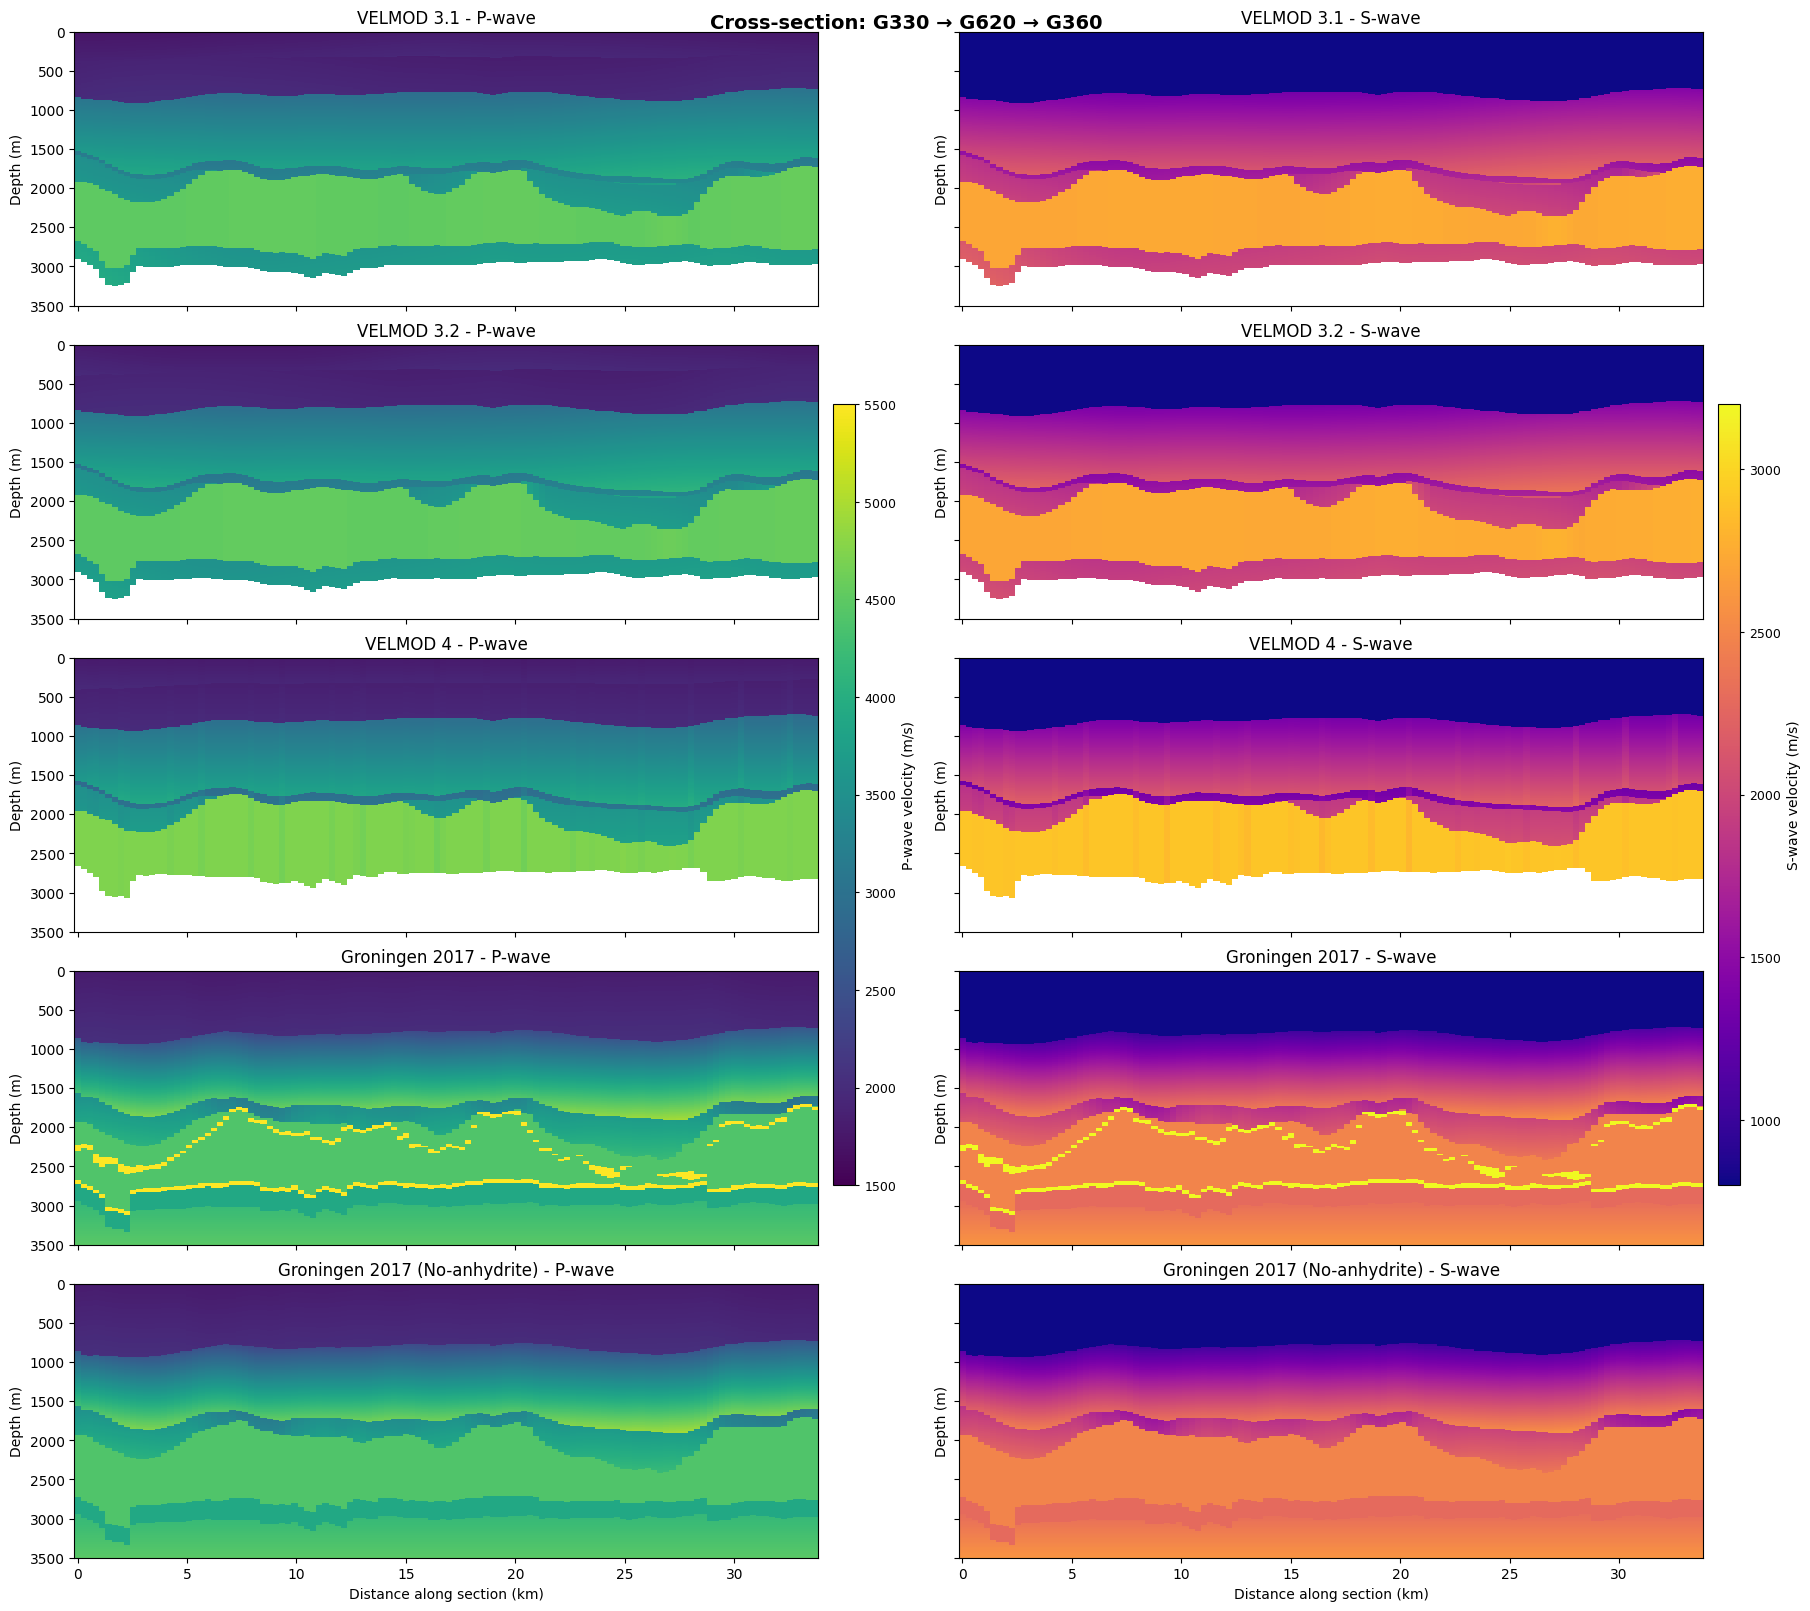

In [14]:
fig, axes = plt.subplots(
    len(MODEL_NAMES),
    2,
    figsize=(18, 16),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

p_handle = None
s_handle = None
for row, model_name in enumerate(MODEL_NAMES):
    p_section = select_mode(section_samples[model_name], "P").transpose(
        "z", "distance_km"
    )
    s_section = select_mode(section_samples[model_name], "S").transpose(
        "z", "distance_km"
    )

    p_handle = p_section.plot(
        x="distance_km",
        y="z",
        ax=axes[row, 0],
        cmap="viridis",
        add_colorbar=False,
        vmin=1500,
        vmax=5500,
    )
    s_handle = s_section.plot(
        x="distance_km",
        y="z",
        ax=axes[row, 1],
        cmap="plasma",
        add_colorbar=False,
        vmin=800,
        vmax=3200,
    )

    axes[row, 0].set_title(f"{MODEL_LABELS[model_name]} - P-wave")
    axes[row, 1].set_title(f"{MODEL_LABELS[model_name]} - S-wave")
    format_depth_axis(axes[row, 0], p_section["z"])
    format_depth_axis(axes[row, 1], s_section["z"])

for row in range(len(MODEL_NAMES) - 1):
    axes[row, 0].set_xlabel("")
    axes[row, 1].set_xlabel("")

axes[-1, 0].set_xlabel("Distance along section (km)")
axes[-1, 1].set_xlabel("Distance along section (km)")

colorbar_kwargs = {
    "shrink": 0.78,
    "fraction": 0.03,
    "pad": 0.02,
    "aspect": 35,
}
p_colorbar = fig.colorbar(
    p_handle,
    ax=axes[:, 0],
    label="P-wave velocity (m/s)",
    **colorbar_kwargs,
)
s_colorbar = fig.colorbar(
    s_handle,
    ax=axes[:, 1],
    label="S-wave velocity (m/s)",
    **colorbar_kwargs,
)

for colorbar in (p_colorbar, s_colorbar):
    colorbar.ax.tick_params(labelsize=9, length=3)

plt.suptitle(
    f"Cross-section: {section_label}",
    fontsize=14,
    fontweight="bold",
    y=0.995,
)
plt.show()

### Cross-Section Differences

Finally, compare each model section against the VELMOD 3.1 baseline on the shared path.


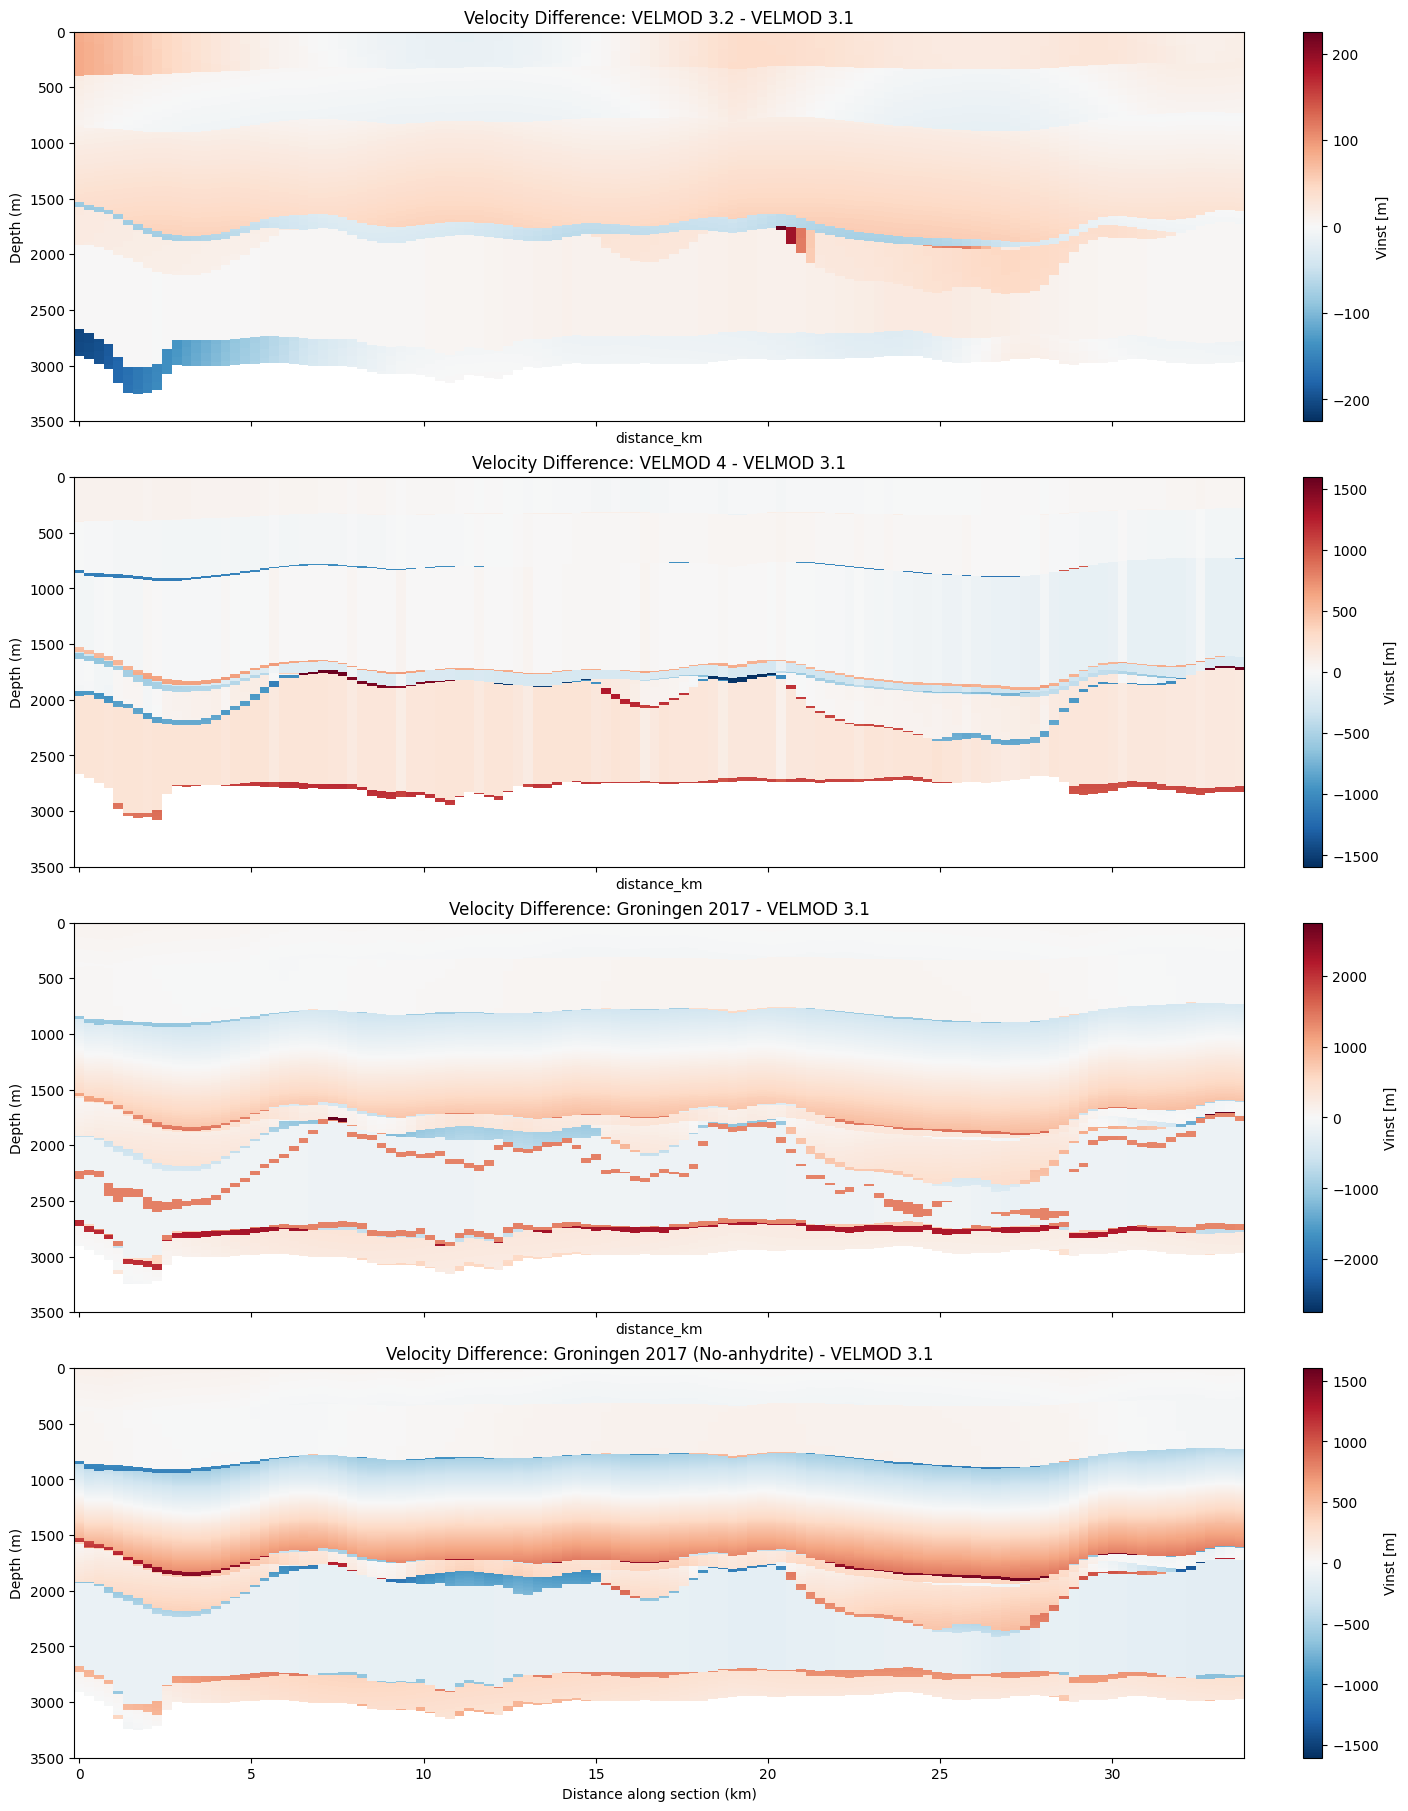

In [15]:
baseline_section = select_mode(section_samples["velmod-3.1"], "P")

fig, axes = plt.subplots(
    len(COMPARISON_MODEL_NAMES),
    1,
    figsize=(14, 4.5 * len(COMPARISON_MODEL_NAMES)),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
axes = np.atleast_1d(axes)

for ax, model_name in zip(axes, COMPARISON_MODEL_NAMES):
    diff = (select_mode(section_samples[model_name], "P") - baseline_section).transpose(
        "z", "distance_km"
    )
    diff.plot(
        x="distance_km",
        y="z",
        ax=ax,
        cmap="RdBu_r",
        center=0,
        add_colorbar=True,
    )
    ax.set_title(f"Velocity Difference: {MODEL_LABELS[model_name]} - VELMOD 3.1")
    format_depth_axis(ax, diff["z"])

axes[-1].set_xlabel("Distance along section (km)")
plt.show()